# Portfolio Risk Analytics — Walkthrough

**Aman Mir**

This notebook walks through the full pipeline interactively: load market data, shape it with the SQL analytics layer, compute the risk metrics with NumPy/pandas, then stress the portfolio with Monte Carlo simulation and mean-variance optimisation.

The same code powers the one-command CLI: `python run_analysis.py` (add `--live` for real market data via yfinance).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

from portfolio_risk import config, database, metrics
from portfolio_risk.data_generator import assets_frame, weights_frame
from portfolio_risk.monte_carlo import simulate_portfolio
from portfolio_risk.optimization import efficient_frontier_analysis

print(f'numpy {np.__version__} | pandas {pd.__version__}')

numpy 2.2.6 | pandas 2.3.3


## 1 · Load the data

The repo ships with a reproducible synthetic dataset: 5 years of daily prices for 8 ETFs spanning equities, duration, credit, gold and real estate, produced by a regime-switching correlated GBM generator (see `src/portfolio_risk/data_generator.py`). Ticker symbols are used for realism; the series are simulated, not market history.

In [2]:
prices = pd.read_csv(REPO / 'data' / 'demo_prices.csv')
print(f"{len(prices):,} rows | {prices['ticker'].nunique()} tickers | "
      f"{prices['date'].min()} -> {prices['date'].max()}")
prices.head()

10,080 rows | 8 tickers | 2021-09-06 -> 2026-07-03


,date,ticker,close,volume
0,2021-09-06,SPY,422.85,88515472
1,2021-09-06,QQQ,352.10,32967606
2,2021-09-06,IWM,182.06,50392321
3,2021-09-06,EFA,71.00,14876966
4,2021-09-06,TLT,99.46,30987062


## 2 · The SQL layer

Prices are loaded into a normalised SQLite schema (`sql/schema.sql`) with foreign-key and CHECK constraints. All heavy time-series shaping is done **in SQL** — window functions, CTEs and ranking — with each query kept as a standalone file under `sql/`. Below: the per-asset summary (joins + aggregates over a windowed CTE).

In [3]:
db_path = REPO / 'data' / 'portfolio.db'
database.initialize_database(db_path, prices, assets_frame(), weights_frame())
database.run_query_file(db_path, 'asset_summary', sql_dir=REPO / 'sql')

,ticker,name,asset_class,portfolio_weight,n_days,total_return_pct,ann_volatility_pct,worst_day_pct,best_day_pct,avg_volume
0,SPY,SPDR S&P 500 ETF,US Large-Cap Equity,0.25,1259,79.16,18.75,-4.62,6.54,89553553
1,QQQ,Invesco Nasdaq-100 ETF,US Tech Equity,0.15,1259,149.09,26.53,-7.49,9.33,56267638
2,TLT,iShares 20+ Yr Treasury Bond ETF,Long-Duration Treasuries,0.15,1259,-19.58,15.62,-2.74,2.99,22379591
3,EFA,iShares MSCI EAFE ETF,Intl Developed Equity,0.10,1259,114.65,19.73,-5.06,6.58,20001004
4,GLD,SPDR Gold Shares,Commodities (Gold),0.10,1259,30.73,14.35,-3.47,3.07,8924517
5,LQD,iShares IG Corporate Bond ETF,Investment-Grade Credit,0.10,1259,30.65,9.28,-2.14,1.98,17143345
6,VNQ,Vanguard Real Estate ETF,US REITs,0.10,1259,67.10,21.78,-5.39,6.95,5565265
7,IWM,iShares Russell 2000 ETF,US Small-Cap Equity,0.05,1259,44.42,23.58,-5.85,6.32,33937886


The rolling-volatility query derives a Bessel-corrected standard deviation from first principles inside a 21-row window frame (SQLite has no `STDDEV` aggregate):

In [4]:
print(database.read_sql_file('rolling_volatility', sql_dir=REPO / 'sql'))
rolling_vol = database.run_query_file(db_path, 'rolling_volatility', sql_dir=REPO / 'sql')
rolling_vol.tail(3)

-- 21-day rolling volatility, annualised (sqrt(252) scaling).
-- Techniques: CTE pipeline + named WINDOW with an explicit ROWS frame.
-- SQLite has no STDDEV aggregate, so the sample standard deviation is
-- derived from first principles inside the window:
--   var = n/(n-1) * ( E[r^2] - E[r]^2 )   (Bessel-corrected)

WITH returns AS (
    SELECT
        date,
        ticker,
        close / LAG(close) OVER (PARTITION BY ticker ORDER BY date) - 1 AS r
    FROM prices
),
rolling AS (
    SELECT
        date,
        ticker,
        AVG(r)     OVER w AS mean_r,
        AVG(r * r) OVER w AS mean_r2,
        COUNT(r)   OVER w AS n_obs
    FROM returns
    WHERE r IS NOT NULL
    WINDOW w AS (
        PARTITION BY ticker
        ORDER BY date
        ROWS BETWEEN 20 PRECEDING AND CURRENT ROW
    )
)
SELECT
    date,
    ticker,
    SQRT(MAX(mean_r2 - mean_r * mean_r, 0.0) * n_obs / (n_obs - 1)) * SQRT(252.0)
        AS ann_volatility_21d
FROM rolling
WHERE n_obs = 21          -- only emit f

,date,ticker,ann_volatility_21d
9909,2026-07-01,VNQ,0.161772
9910,2026-07-02,VNQ,0.158408
9911,2026-07-03,VNQ,0.150979


## 3 · Risk & performance metrics

The Python risk engine computes annualised return/volatility, Sharpe, Sortino, Calmar, CAPM beta, max drawdown, and daily VaR/CVaR (historical, parametric and — in the next section — simulated). Conventions: 252 trading days, 2% risk-free rate, VaR reported as a positive loss.

In [5]:
returns = metrics.daily_returns(metrics.to_wide(prices))
port_r = metrics.portfolio_returns(returns, config.PORTFOLIO_WEIGHTS)
summary = metrics.summary_table(returns, config.PORTFOLIO_WEIGHTS)
summary.round(3)

,weight,ann_return,ann_volatility,sharpe,sortino,max_drawdown,calmar,var_95_daily,cvar_95_daily,var_99_daily,beta_vs_SPY
EFA,0.10,0.165,0.197,0.736,1.120,-0.192,0.861,0.019,0.024,0.028,0.833
GLD,0.10,0.055,0.144,0.244,0.354,-0.225,0.245,0.014,0.018,0.020,0.051
IWM,0.05,0.076,0.236,0.239,0.358,-0.415,0.184,0.022,0.029,0.031,1.058
LQD,0.10,0.055,0.093,0.377,0.540,-0.145,0.378,0.009,0.012,0.014,0.170
QQQ,0.15,0.200,0.265,0.680,1.049,-0.350,0.573,0.024,0.033,0.035,1.241
SPY,0.25,0.124,0.188,0.553,0.847,-0.379,0.327,0.018,0.023,0.026,1.000
TLT,0.15,-0.043,0.156,-0.401,-0.554,-0.409,-0.104,0.017,0.020,0.022,-0.267
VNQ,0.10,0.108,0.218,0.405,0.620,-0.482,0.224,0.020,0.025,0.027,0.745
PORTFOLIO,1.00,0.106,0.128,0.669,1.037,-0.207,0.510,0.012,0.015,0.016,0.629


Two things worth noticing. First, diversification is visible in the numbers: portfolio volatility (~12.8%) sits about six points below the weighted average of its holdings (~18.7%), because bonds and gold are lowly or negatively correlated with equities. Second, historical CVaR (~1.5%) exceeds VaR (~1.2%) — the tail is fatter than the threshold suggests, which is exactly why desks report expected shortfall alongside VaR.

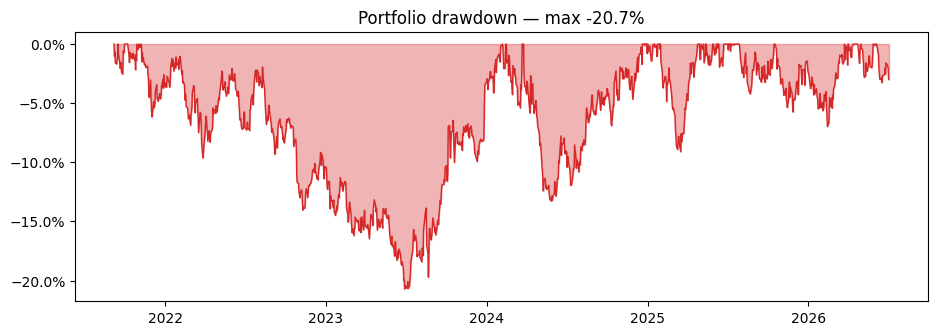

In [6]:
dd = metrics.drawdown_series(port_r)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(dd.index, dd, 0, color='#d62828', alpha=0.35)
ax.plot(dd.index, dd, color='#d62828', lw=1)
ax.set_title(f'Portfolio drawdown — max {dd.min():.1%}')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
plt.show()

## 4 · Monte Carlo simulation

10,000 one-year wealth paths: daily mean vector and covariance matrix are estimated from history, correlated shocks are generated via Cholesky factorisation, and paths are compounded from $100,000. The 5th percentile of terminal wealth gives the 1-year 95% VaR; the mean beyond it gives CVaR.

In [7]:
mc = simulate_portfolio(returns, config.PORTFOLIO_WEIGHTS, n_sims=10_000, seed=7)
pd.Series(mc.summary, name='value').round(4).to_frame()

,value
median_terminal,110330.0231
mean_terminal,111246.9815
p5_terminal,89649.2298
p95_terminal,135903.3951
var_95_pct,0.1035
cvar_95_pct,0.1508
prob_loss,0.2169
hist_daily_var_95,0.0116


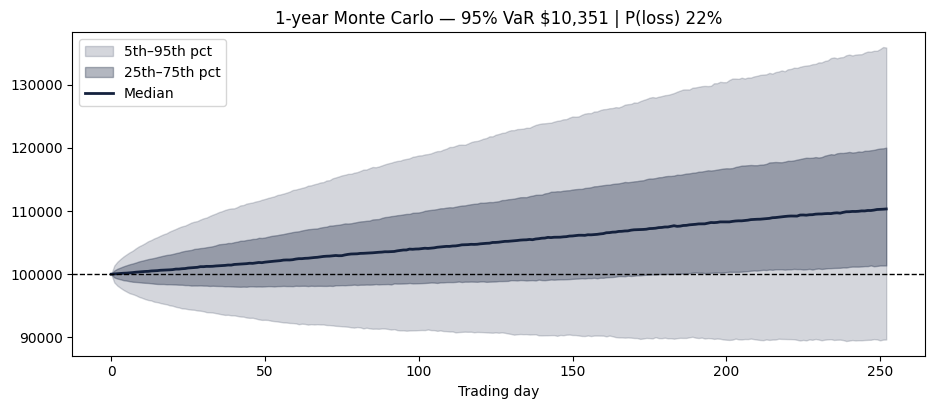

In [8]:
bands = mc.percentile_bands
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(bands.index, bands['p5'], bands['p95'], alpha=0.18, color='#14213d', label='5th–95th pct')
ax.fill_between(bands.index, bands['p25'], bands['p75'], alpha=0.32, color='#14213d', label='25th–75th pct')
ax.plot(bands.index, bands['p50'], color='#14213d', lw=2, label='Median')
ax.axhline(mc.initial_value, ls='--', c='black', lw=1)
ax.set_title(f'1-year Monte Carlo — 95% VaR ${mc.var_amount:,.0f} | P(loss) {mc.prob_loss:.0%}')
ax.set_xlabel('Trading day'); ax.legend()
plt.show()

## 5 · Efficient frontier

The minimum-variance frontier is computed in closed form from the classic Markowitz algebra (A = 1'S⁻¹1, B = 1'S⁻¹mu, C = mu'S⁻¹mu) and validated against a 20,000-portfolio long-only random cloud. The model portfolio plots close to — but not on — the frontier; the gap is the price of holding an intuitive, liquid allocation.

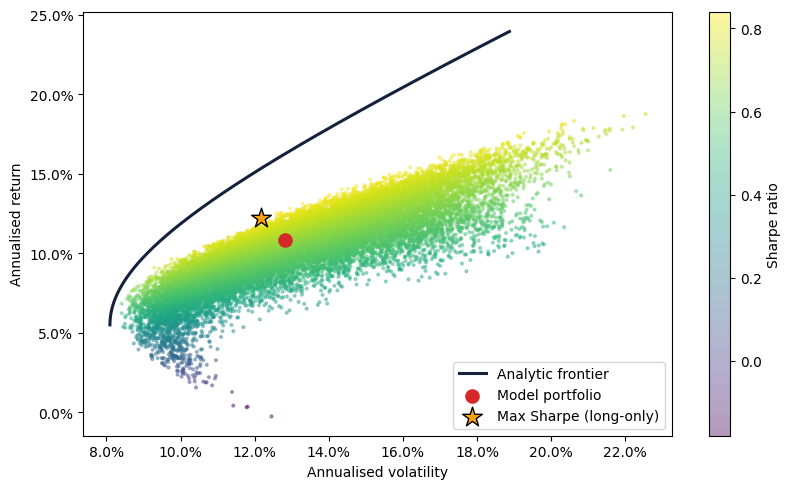

In [9]:
fr = efficient_frontier_analysis(returns, config.PORTFOLIO_WEIGHTS)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
sc = ax.scatter(fr.cloud['vol'], fr.cloud['ret'], c=fr.cloud['sharpe'], cmap='viridis', s=4, alpha=0.4)
fig.colorbar(sc, ax=ax, label='Sharpe ratio')
ax.plot(fr.frontier['vol'], fr.frontier['ret'], color='#14213d', lw=2.2, label='Analytic frontier')
ax.scatter([fr.current_point[0]], [fr.current_point[1]], color='#d62828', s=90, zorder=5, label='Model portfolio')
ax.scatter([fr.max_sharpe_point[0]], [fr.max_sharpe_point[1]], marker='*', color='#fca311', s=220, edgecolor='k', zorder=5, label='Max Sharpe (long-only)')
pct = plt.matplotlib.ticker.PercentFormatter(xmax=1.0)
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel('Annualised volatility'); ax.set_ylabel('Annualised return')
ax.legend(loc='lower right')
plt.show()

In [10]:
fr.max_sharpe_weights[fr.max_sharpe_weights > 0.01].rename('max-Sharpe weight').to_frame()

,max-Sharpe weight
ticker,
EFA,0.3339
GLD,0.1317
LQD,0.3213
QQQ,0.1657
TLT,0.0281
VNQ,0.0174


## 6 · Takeaways & limitations

The three VaR figures disagree by design: historical VaR is assumption-free but backward-looking, parametric VaR understates fat tails, and Monte Carlo VaR is forward-looking but inherits the normality of its shocks. The spread between them is information, not error.

Honest limitations: normal shocks (no jumps or skew), covariance estimated on the full sample (regimes are blended), fixed daily-rebalanced weights, and no transaction costs. Each one is a concrete next step — bootstrap or Student-t shocks, EWMA/regime-aware covariance, and a rebalancing-cost model.